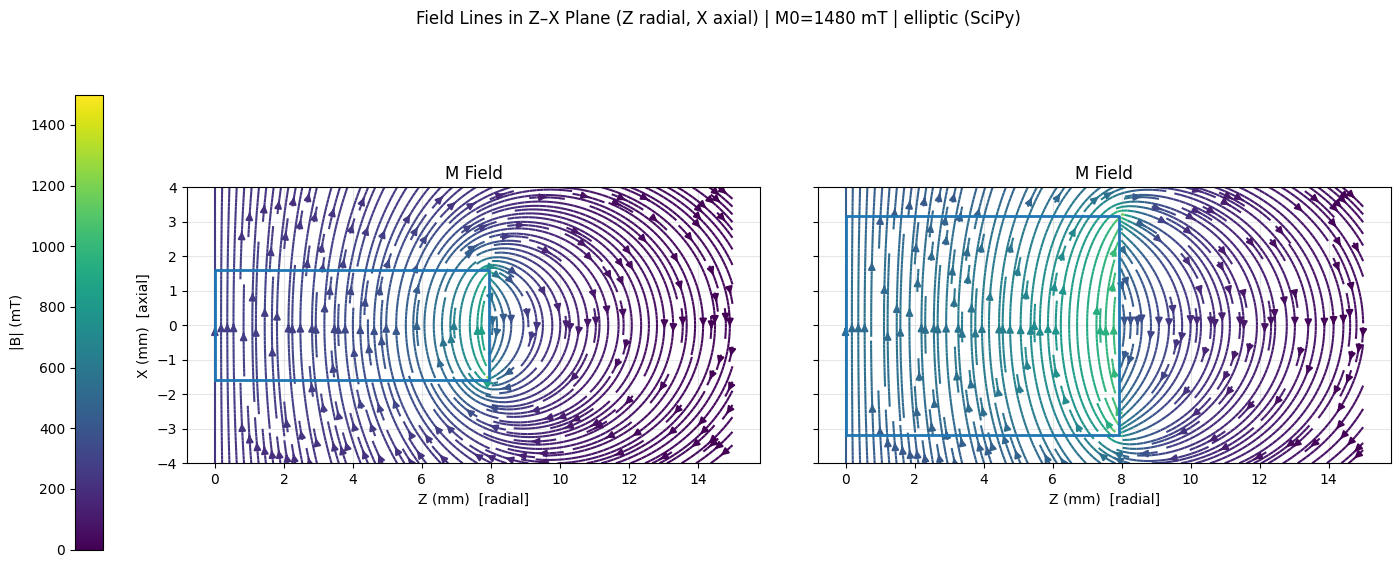

In [15]:
"""
Side-by-side plots for BOTH magnets (two heights) in the Z–X plane (mm),
with streamline color showing |B| in mT (shared color scale + ONE colorbar
moved to the LEFT of both plots).
"""

import numpy as np
import matplotlib.pyplot as plt

MU0 = 4e-7 * np.pi

# ---------------------- YOUR PARAMETERS ----------------------
M0_mT = 1480  # mT
shape = [
    [5 * 25.4 / 16, 25.4 / 8],      # radius_mm, height_mm
    [5 * 25.4 / 16, 2 * 25.4 / 8],  # radius_mm, height_mm
]
# ------------------------------------------------------------

# ---------------------- PLOT / GRID SETTINGS (mm) ----------------------
X_min_mm, X_max_mm = -4.0, 4.0
Z_max_mm = 15.0   # Z >= 0

stream_density = 2.4
n_loops = 80

clip_vec_T = 2.0

# Optional: cap colorbar at this (mT). Set to None to auto-scale.
color_clip_mT = 1500.0
# ------------------------------------------------------------

# ---- Try fast elliptic-integral loop field ----
try:
    from scipy.special import ellipk, ellipe
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

if HAVE_SCIPY:
    nZ, nX = 300, 220
    NPHI_NUMERIC = 0
else:
    nZ, nX = 170, 140
    NPHI_NUMERIC = 240


def loop_field_rz_elliptic(r, z, a_loop, I):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    Br = np.zeros_like(r)
    Bz = np.zeros_like(r)

    ap = a_loop + r
    am = a_loop - r
    Q = ap * ap + z * z
    P = am * am + z * z

    with np.errstate(divide="ignore", invalid="ignore"):
        m = 4.0 * a_loop * r / Q  # m=k^2

    K = ellipk(m)
    E = ellipe(m)
    denom = np.sqrt(Q)

    off_axis = r > 1e-12
    if np.any(off_axis):
        r0 = r[off_axis]
        z0 = z[off_axis]
        P0 = P[off_axis]
        denom0 = denom[off_axis]
        K0 = K[off_axis]
        E0 = E[off_axis]

        Br[off_axis] = (MU0 * I * z0) / (2.0 * np.pi * r0 * denom0) * (
            -K0 + (a_loop * a_loop + r0 * r0 + z0 * z0) / P0 * E0
        )

        Bz[off_axis] = (MU0 * I) / (2.0 * np.pi * denom0) * (
            K0 + (a_loop * a_loop - r0 * r0 - z0 * z0) / P0 * E0
        )

    on_axis = ~off_axis
    if np.any(on_axis):
        z1 = z[on_axis]
        Bz[on_axis] = MU0 * I * a_loop * a_loop / (2.0 * (a_loop * a_loop + z1 * z1) ** 1.5)

    return Br, Bz


def loop_field_xyz_numeric(x, y, z, a_loop, I, nphi=240):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    phi = np.linspace(0.0, 2.0 * np.pi, nphi, endpoint=False)
    dphi = phi[1] - phi[0]

    xw = a_loop * np.cos(phi)
    yw = a_loop * np.sin(phi)

    dlx = -a_loop * np.sin(phi) * dphi
    dly =  a_loop * np.cos(phi) * dphi

    X = x[..., None]
    Y = y[..., None]
    Z = z[..., None]

    rx = X - xw[None, ...]
    ry = Y - yw[None, ...]
    rz = Z

    R3 = (rx * rx + ry * ry + rz * rz) ** 1.5 + 1e-30

    cx = dly * rz
    cy = -dlx * rz
    cz = dlx * ry - dly * rx

    pref = MU0 * I / (4.0 * np.pi)
    Bx = pref * np.sum(cx / R3, axis=-1)
    By = pref * np.sum(cy / R3, axis=-1)
    Bz = pref * np.sum(cz / R3, axis=-1)
    return Bx, By, Bz


def loop_field_rz(r, z, a_loop, I):
    if HAVE_SCIPY:
        return loop_field_rz_elliptic(r, z, a_loop, I)
    Bx, _, Bz = loop_field_xyz_numeric(r, 0.0, z, a_loop, I, nphi=NPHI_NUMERIC)
    return Bx, Bz


def cylinder_field_ZX(Z_rad_m, X_ax_m, radius_m, height_m, Br_T, nloops):
    M_Apm = Br_T / MU0  # Treat Br_T as polarization J (Tesla): M = J/mu0

    r = Z_rad_m
    x = X_ax_m

    x_centers = np.linspace(-height_m / 2.0, height_m / 2.0, nloops)
    dx = x_centers[1] - x_centers[0] if nloops > 1 else height_m
    I_loop = M_Apm * dx

    Br_total = np.zeros_like(r)
    Bx_total = np.zeros_like(r)

    for x0 in x_centers:
        Br_i, Bax_i = loop_field_rz(r, x - x0, radius_m, I_loop)
        Br_total += Br_i
        Bx_total += Bax_i

    return Br_total, Bx_total  # (BZ radial, BX axial)


def compute_fields_for_shape(radius_mm, height_mm, Zg_mm, Xg_mm, Br_T):
    radius_m = radius_mm * 1e-3
    height_m = height_mm * 1e-3

    Zg_m = Zg_mm * 1e-3
    Xg_m = Xg_mm * 1e-3

    BZ_raw, BX_raw = cylinder_field_ZX(Zg_m, Xg_m, radius_m, height_m, Br_T, n_loops)

    # magnitude for coloring (mT)
    Bmag_mT = 1e3 * np.sqrt(BZ_raw * BZ_raw + BX_raw * BX_raw)

    # clip vectors for stream stability (Tesla)
    BZ, BX = BZ_raw.copy(), BX_raw.copy()
    Bmag_T = np.sqrt(BZ * BZ + BX * BX)
    if clip_vec_T is not None and clip_vec_T > 0:
        scale = np.minimum(1.0, clip_vec_T / (Bmag_T + 1e-30))
        BZ *= scale
        BX *= scale

    return BZ, BX, Bmag_mT


def main():
    Br_T = M0_mT * 1e-3  # mT -> T

    # Shared grid (mm): x-axis=Z (radial), y-axis=X (axial)
    Z_mm = np.linspace(0.0, Z_max_mm, nZ)
    X_mm = np.linspace(X_min_mm, X_max_mm, nX)
    Zg_mm, Xg_mm = np.meshgrid(Z_mm, X_mm)  # (nX, nZ)

    results = []
    max_mT = 0.0
    for (radius_mm, height_mm) in shape:
        BZ, BX, Bmag_mT = compute_fields_for_shape(radius_mm, height_mm, Zg_mm, Xg_mm, Br_T)
        max_mT = max(max_mT, float(np.max(Bmag_mT)))
        results.append((radius_mm, height_mm, BZ, BX, Bmag_mT))

    # Shared color scaling
    vmax = max_mT if (color_clip_mT is None) else min(color_clip_mT, max_mT)
    vmin = 0.0
    cmap = plt.get_cmap()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True, sharey=True)

    # Make room on the LEFT for the colorbar
    fig.subplots_adjust(left=0.12, right=0.98, wspace=0.10)

    # Create a dedicated colorbar axis on the LEFT: [left, bottom, width, height] in figure coords
    cax = fig.add_axes([0.04, 0.15, 0.02, 0.70])

    for ax, (radius_mm, height_mm, BZ, BX, Bmag_mT) in zip(axes, results):
        color_vals = np.clip(Bmag_mT, vmin, vmax)

        strm = ax.streamplot(
            Z_mm, X_mm, BZ, BX,
            color=color_vals,
            cmap=cmap,
            density=stream_density,
            arrowsize=1.0,
            minlength=0.05,
        )
        strm.lines.set_clim(vmin, vmax)

        # Magnet outline (mm)
        rect_Z = [0, radius_mm, radius_mm, 0, 0]
        rect_X = [-height_mm / 2, -height_mm / 2, height_mm / 2, height_mm / 2, -height_mm / 2]
        ax.plot(rect_Z, rect_X, linewidth=2)

        ax.set_title("M Field")
        ax.set_xlabel("Z (mm)  [radial]")
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")

    axes[0].set_ylabel("X (mm)  [axial]")

    # One shared colorbar using the same normalization/cmap, placed on the LEFT axis (cax)
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("|B| (mT)")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.tick_left()

    fig.suptitle(
        f"Field Lines in Z–X Plane (Z radial, X axial) | M0={M0_mT} mT | "
        f"{'elliptic (SciPy)' if HAVE_SCIPY else 'numeric (no SciPy)'}",
        y=0.98,
    )

    plt.show()


if __name__ == "__main__":
    main()

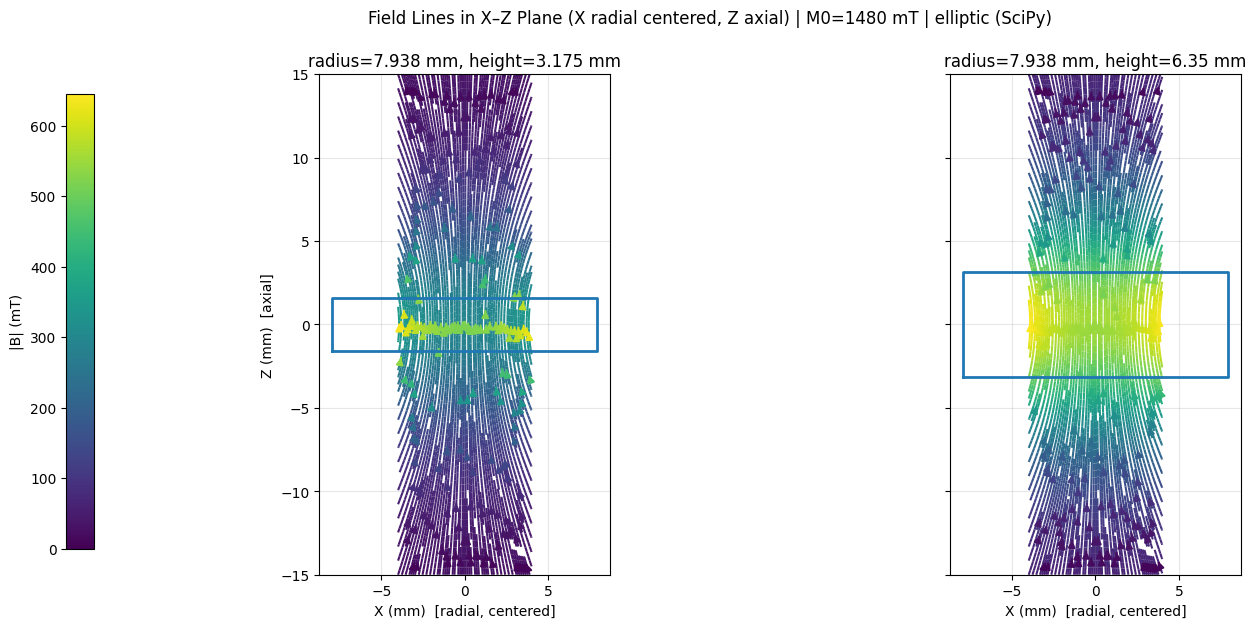

In [16]:
"""
Side-by-side plots for BOTH magnets (two heights) in the X–Z plane (mm),
where Z is AXIAL and X is RADIAL (full, centered cross-section).
Streamline color shows |B| in mT (shared color scale + ONE colorbar on LEFT).
"""

import numpy as np
import matplotlib.pyplot as plt

MU0 = 4e-7 * np.pi

# ---------------------- YOUR PARAMETERS ----------------------
M0_mT = 1480  # mT  (treated as Br in Tesla for J=Br and M=J/mu0)
shape = [
    [5 * 25.4 / 16, 25.4 / 8],      # radius_mm, height_mm
    [5 * 25.4 / 16, 2 * 25.4 / 8],  # radius_mm, height_mm
]
# ------------------------------------------------------------

# ---------------------- PLOT / GRID SETTINGS (mm) ----------------------
# X = radial (centered, can be negative), Z = axial (centered)
X_rad_min_mm, X_rad_max_mm = -4.0, 4.0
Z_ax_min_mm,  Z_ax_max_mm  = -15.0, 15.0

stream_density = 2.4
n_loops = 80

clip_vec_T = 2.0

# Optional: cap colorbar at this (mT). Set to None to auto-scale.
color_clip_mT = 1500.0
# ------------------------------------------------------------

# ---- Elliptic-integral loop field (fast) ----
try:
    from scipy.special import ellipk, ellipe
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

if HAVE_SCIPY:
    nZ, nX = 300, 220   # nZ = axial samples, nX = radial samples
    NPHI_NUMERIC = 0
else:
    nZ, nX = 170, 140
    NPHI_NUMERIC = 240


def loop_field_rz_elliptic(r, z, a_loop, I):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    Br = np.zeros_like(r)
    Bz = np.zeros_like(r)

    ap = a_loop + r
    am = a_loop - r
    Q = ap * ap + z * z
    P = am * am + z * z

    with np.errstate(divide="ignore", invalid="ignore"):
        m = 4.0 * a_loop * r / Q  # m = k^2

    K = ellipk(m)
    E = ellipe(m)
    denom = np.sqrt(Q)

    off_axis = r > 1e-12
    if np.any(off_axis):
        r0 = r[off_axis]
        z0 = z[off_axis]
        P0 = P[off_axis]
        denom0 = denom[off_axis]
        K0 = K[off_axis]
        E0 = E[off_axis]

        Br[off_axis] = (MU0 * I * z0) / (2.0 * np.pi * r0 * denom0) * (
            -K0 + (a_loop * a_loop + r0 * r0 + z0 * z0) / P0 * E0
        )

        Bz[off_axis] = (MU0 * I) / (2.0 * np.pi * denom0) * (
            K0 + (a_loop * a_loop - r0 * r0 - z0 * z0) / P0 * E0
        )

    on_axis = ~off_axis
    if np.any(on_axis):
        z1 = z[on_axis]
        Bz[on_axis] = MU0 * I * a_loop * a_loop / (2.0 * (a_loop * a_loop + z1 * z1) ** 1.5)

    return Br, Bz


def loop_field_xyz_numeric(x, y, z, a_loop, I, nphi=240):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    phi = np.linspace(0.0, 2.0 * np.pi, nphi, endpoint=False)
    dphi = phi[1] - phi[0]

    xw = a_loop * np.cos(phi)
    yw = a_loop * np.sin(phi)

    dlx = -a_loop * np.sin(phi) * dphi
    dly =  a_loop * np.cos(phi) * dphi

    X = x[..., None]
    Y = y[..., None]
    Z = z[..., None]

    rx = X - xw[None, ...]
    ry = Y - yw[None, ...]
    rz = Z

    R3 = (rx * rx + ry * ry + rz * rz) ** 1.5 + 1e-30

    cx = dly * rz
    cy = -dlx * rz
    cz = dlx * ry - dly * rx

    pref = MU0 * I / (4.0 * np.pi)
    Bx = pref * np.sum(cx / R3, axis=-1)
    By = pref * np.sum(cy / R3, axis=-1)
    Bz = pref * np.sum(cz / R3, axis=-1)
    return Bx, By, Bz


def loop_field_rz(r, z, a_loop, I):
    if HAVE_SCIPY:
        return loop_field_rz_elliptic(r, z, a_loop, I)
    Bx, _, Bz = loop_field_xyz_numeric(r, 0.0, z, a_loop, I, nphi=NPHI_NUMERIC)
    return Bx, Bz


def cylinder_field_rz(r_m, z_m, radius_m, height_m, Br_T, nloops):
    """
    Axisymmetric, axially magnetized cylinder modeled as a stack of loops.
    Returns (Br, Bz) at (r,z).
    """
    M_Apm = Br_T / MU0  # treat Br_T as polarization J (Tesla): M = J/mu0

    z_centers = np.linspace(-height_m / 2.0, height_m / 2.0, nloops)
    dz = z_centers[1] - z_centers[0] if nloops > 1 else height_m
    I_loop = M_Apm * dz

    Br_total = np.zeros_like(r_m)
    Bz_total = np.zeros_like(r_m)

    for z0 in z_centers:
        Br_i, Bz_i = loop_field_rz(r_m, z_m - z0, radius_m, I_loop)
        Br_total += Br_i
        Bz_total += Bz_i

    return Br_total, Bz_total


def compute_fields_for_shape(radius_mm, height_mm, Xg_mm, Zg_mm, Br_T):
    """
    Inputs are Cartesian (X,Z) in mm for plotting a centered cross-section.
    Internally convert to cylindrical r=|X|.
    Returns (Bx, Bz, |B|_mT) on the same grid.
    """
    radius_m = radius_mm * 1e-3
    height_m = height_mm * 1e-3

    Xg_m = Xg_mm * 1e-3
    Zg_m = Zg_mm * 1e-3

    r_m = np.abs(Xg_m)
    z_m = Zg_m

    Br_raw, Bz_raw = cylinder_field_rz(r_m, z_m, radius_m, height_m, Br_T, n_loops)

    # Convert cylindrical Br to Cartesian Bx (changes sign for X<0)
    Bx_raw = Br_raw * np.sign(Xg_m)

    # magnitude for coloring (mT)
    Bmag_mT = 1e3 * np.sqrt(Bx_raw * Bx_raw + Bz_raw * Bz_raw)

    # clip vectors for stream stability (Tesla)
    Bx, Bz = Bx_raw.copy(), Bz_raw.copy()
    Bmag_T = np.sqrt(Bx * Bx + Bz * Bz)
    if clip_vec_T is not None and clip_vec_T > 0:
        scale = np.minimum(1.0, clip_vec_T / (Bmag_T + 1e-30))
        Bx *= scale
        Bz *= scale

    return Bx, Bz, Bmag_mT


def main():
    Br_T = M0_mT * 1e-3  # mT -> T

    # Shared grid (mm): x-axis=X (radial), y-axis=Z (axial)
    X_mm = np.linspace(X_rad_min_mm, X_rad_max_mm, nX)
    Z_mm = np.linspace(Z_ax_min_mm, Z_ax_max_mm, nZ)
    Xg_mm, Zg_mm = np.meshgrid(X_mm, Z_mm)  # (nZ, nX)

    results = []
    max_mT = 0.0
    for (radius_mm, height_mm) in shape:
        Bx, Bz, Bmag_mT = compute_fields_for_shape(radius_mm, height_mm, Xg_mm, Zg_mm, Br_T)
        max_mT = max(max_mT, float(np.max(Bmag_mT)))
        results.append((radius_mm, height_mm, Bx, Bz, Bmag_mT))

    # Shared color scaling
    vmax = max_mT if (color_clip_mT is None) else min(color_clip_mT, max_mT)
    vmin = 0.0
    cmap = plt.get_cmap()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True, sharey=True)

    # Make room on the LEFT for the colorbar
    fig.subplots_adjust(left=0.12, right=0.98, wspace=0.10)

    # Dedicated colorbar axis on the LEFT: [left, bottom, width, height] in figure coords
    cax = fig.add_axes([0.04, 0.15, 0.02, 0.70])

    for ax, (radius_mm, height_mm, Bx, Bz, Bmag_mT) in zip(axes, results):
        color_vals = np.clip(Bmag_mT, vmin, vmax)

        strm = ax.streamplot(
            X_mm, Z_mm, Bx, Bz,
            color=color_vals,
            cmap=cmap,
            density=stream_density,
            arrowsize=1.0,
            minlength=0.05,
        )
        strm.lines.set_clim(vmin, vmax)

        # Magnet outline (full diameter, centered) in X–Z (mm)
        rect_X = [-radius_mm,  radius_mm,  radius_mm, -radius_mm, -radius_mm]
        rect_Z = [-height_mm / 2, -height_mm / 2, height_mm / 2, height_mm / 2, -height_mm / 2]
        ax.plot(rect_X, rect_Z, linewidth=2)

        ax.set_title(f"radius={radius_mm:.4g} mm, height={height_mm:.4g} mm")
        ax.set_xlabel("X (mm)  [radial, centered]")
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")

    axes[0].set_ylabel("Z (mm)  [axial]")

    # One shared colorbar on the LEFT
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("|B| (mT)")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.tick_left()

    fig.suptitle(
        f"Field Lines in X–Z Plane (X radial centered, Z axial) | M0={M0_mT} mT | "
        f"{'elliptic (SciPy)' if HAVE_SCIPY else 'numeric (no SciPy)'}",
        y=0.98,
    )

    plt.show()


if __name__ == "__main__":
    main()

In [17]:
"""
Two-panel "isodose-style" plots (iso-|B| contours) for a cylinder magnet
in the centered X–Z plane (mm).

Adds:
- red contour at 10 mT
- purple contour at 15 mT
- a shared legend (no contour labels on the plot)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MU0 = 4e-7 * np.pi

# ---------------------- YOUR PARAMETERS ----------------------
M0_mT = 1480  # mT
shape = [
    [5 * 25.4 / 16, 25.4 / 8],      # radius_mm, height_mm
    [5 * 25.4 / 16, 2 * 25.4 / 8],  # radius_mm, height_mm
]
# ------------------------------------------------------------

# ---------------------- GRID (mm) ----------------------
X_rad_min_mm, X_rad_max_mm = -15.0, 15.0
Z_ax_min_mm,  Z_ax_max_mm  = -20.0, 40.0

nZ, nX = 300, 220
n_loops = 80

# Plot look
SHOW_FILLED = True
N_LEVELS_FILL = 40
N_LEVELS_LINES = 14
LINE_WIDTH = 1.0

# Highlighted iso-lines (mT)
ISO_10_mT = 10.0
ISO_15_mT = 15.0
ISO_LINEWIDTH = 2.5

# Optional: cap colorbar at this (mT). Set to None to auto-scale.
color_clip_mT = 1500.0
# ------------------------------------------------------------

# ---- Elliptic-integral loop field (fast) ----
try:
    from scipy.special import ellipk, ellipe
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False
    NPHI_NUMERIC = 240


def loop_field_rz_elliptic(r, z, a_loop, I):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    Br = np.zeros_like(r)
    Bz = np.zeros_like(r)

    ap = a_loop + r
    am = a_loop - r
    Q = ap * ap + z * z
    P = am * am + z * z

    with np.errstate(divide="ignore", invalid="ignore"):
        m = 4.0 * a_loop * r / Q  # m = k^2

    K = ellipk(m)
    E = ellipe(m)
    denom = np.sqrt(Q)

    off_axis = r > 1e-12
    if np.any(off_axis):
        r0 = r[off_axis]
        z0 = z[off_axis]
        P0 = P[off_axis]
        denom0 = denom[off_axis]
        K0 = K[off_axis]
        E0 = E[off_axis]

        Br[off_axis] = (MU0 * I * z0) / (2.0 * np.pi * r0 * denom0) * (
            -K0 + (a_loop * a_loop + r0 * r0 + z0 * z0) / P0 * E0
        )

        Bz[off_axis] = (MU0 * I) / (2.0 * np.pi * denom0) * (
            K0 + (a_loop * a_loop - r0 * r0 - z0 * z0) / P0 * E0
        )

    on_axis = ~off_axis
    if np.any(on_axis):
        z1 = z[on_axis]
        Bz[on_axis] = MU0 * I * a_loop * a_loop / (2.0 * (a_loop * a_loop + z1 * z1) ** 1.5)

    return Br, Bz



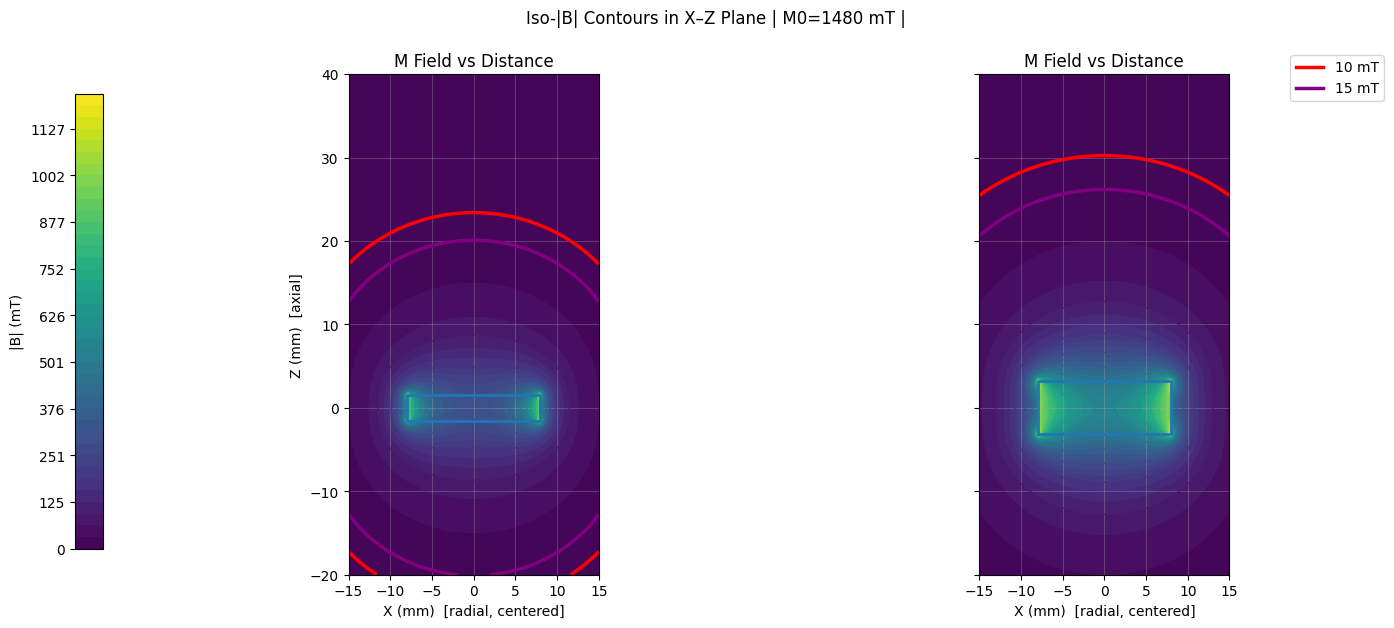

In [20]:

def loop_field_xyz_numeric(x, y, z, a_loop, I, nphi=240):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    phi = np.linspace(0.0, 2.0 * np.pi, nphi, endpoint=False)
    dphi = phi[1] - phi[0]

    xw = a_loop * np.cos(phi)
    yw = a_loop * np.sin(phi)

    dlx = -a_loop * np.sin(phi) * dphi
    dly =  a_loop * np.cos(phi) * dphi

    X = x[..., None]
    Y = y[..., None]
    Z = z[..., None]

    rx = X - xw[None, ...]
    ry = Y - yw[None, ...]
    rz = Z

    R3 = (rx * rx + ry * ry + rz * rz) ** 1.5 + 1e-30

    cx = dly * rz
    cy = -dlx * rz
    cz = dlx * ry - dly * rx

    pref = MU0 * I / (4.0 * np.pi)
    Bx = pref * np.sum(cx / R3, axis=-1)
    By = pref * np.sum(cy / R3, axis=-1)
    Bz = pref * np.sum(cz / R3, axis=-1)
    return Bx, By, Bz


def loop_field_rz(r, z, a_loop, I):
    if HAVE_SCIPY:
        return loop_field_rz_elliptic(r, z, a_loop, I)
    Bx, _, Bz = loop_field_xyz_numeric(r, 0.0, z, a_loop, I, nphi=NPHI_NUMERIC)
    return Bx, Bz


def cylinder_field_rz(r_m, z_m, radius_m, height_m, Br_T, nloops):
    M_Apm = Br_T / MU0

    z_centers = np.linspace(-height_m / 2.0, height_m / 2.0, nloops)
    dz = z_centers[1] - z_centers[0] if nloops > 1 else height_m
    I_loop = M_Apm * dz

    Br_total = np.zeros_like(r_m)
    Bz_total = np.zeros_like(r_m)

    for z0 in z_centers:
        Br_i, Bz_i = loop_field_rz(r_m, z_m - z0, radius_m, I_loop)
        Br_total += Br_i
        Bz_total += Bz_i

    return Br_total, Bz_total


def compute_Bmag_for_shape(radius_mm, height_mm, Xg_mm, Zg_mm, Br_T):
    radius_m = radius_mm * 1e-3
    height_m = height_mm * 1e-3

    Xg_m = Xg_mm * 1e-3
    Zg_m = Zg_mm * 1e-3

    r_m = np.abs(Xg_m)
    z_m = Zg_m

    Br, Bz = cylinder_field_rz(r_m, z_m, radius_m, height_m, Br_T, n_loops)
    Bx = Br * np.sign(Xg_m)

    Bmag_mT = 1e3 * np.sqrt(Bx * Bx + Bz * Bz)
    return Bmag_mT


def _add_iso(ax, X_mm, Z_mm, Bplot, level_mT, color, lw):
    bmin = float(np.nanmin(Bplot))
    bmax = float(np.nanmax(Bplot))
    if bmin <= level_mT <= bmax:
        ax.contour(
            X_mm, Z_mm, Bplot,
            levels=[level_mT],
            colors=[color],
            linewidths=lw,
        )


def main():
    Br_T = M0_mT * 1e-3

    X_mm = np.linspace(X_rad_min_mm, X_rad_max_mm, nX)
    Z_mm = np.linspace(Z_ax_min_mm, Z_ax_max_mm, nZ)
    Xg_mm, Zg_mm = np.meshgrid(X_mm, Z_mm)

    results = []
    max_mT = 0.0
    for (radius_mm, height_mm) in shape:
        Bmag_mT = compute_Bmag_for_shape(radius_mm, height_mm, Xg_mm, Zg_mm, Br_T)
        max_mT = max(max_mT, float(np.max(Bmag_mT)))
        results.append((radius_mm, height_mm, Bmag_mT))

    vmax = max_mT if (color_clip_mT is None) else min(color_clip_mT, max_mT)
    vmin = 0.0

    fill_levels = np.linspace(vmin, vmax, N_LEVELS_FILL) if SHOW_FILLED else None
    line_levels = np.linspace(vmin, vmax, N_LEVELS_LINES)

    cmap = plt.get_cmap()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.12, right=0.98, wspace=0.10)

    cax = fig.add_axes([0.04, 0.15, 0.02, 0.70])

    mappable_for_cbar = None

    for ax, (radius_mm, height_mm, Bmag_mT) in zip(axes, results):
        Bplot = np.clip(Bmag_mT, vmin, vmax)

        if SHOW_FILLED:
            cf = ax.contourf(X_mm, Z_mm, Bplot, levels=fill_levels, cmap=cmap)
            mappable_for_cbar = cf

        ax.contour(X_mm, Z_mm, Bplot, levels=line_levels, linewidths=LINE_WIDTH)

        _add_iso(ax, X_mm, Z_mm, Bplot, ISO_10_mT, color="red",    lw=ISO_LINEWIDTH)
        _add_iso(ax, X_mm, Z_mm, Bplot, ISO_15_mT, color="purple", lw=ISO_LINEWIDTH)

        rect_X = [-radius_mm,  radius_mm,  radius_mm, -radius_mm, -radius_mm]
        rect_Z = [-height_mm / 2, -height_mm / 2, height_mm / 2, height_mm / 2, -height_mm / 2]
        ax.plot(rect_X, rect_Z, linewidth=2)

        ax.set_title("M Field vs Distance")
        ax.set_xlabel("X (mm)  [radial, centered]")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Z (mm)  [axial]")

    # Shared colorbar
    if mappable_for_cbar is None:
        from matplotlib.cm import ScalarMappable
        from matplotlib.colors import Normalize
        sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
        sm.set_array([])
        mappable_for_cbar = sm

    cbar = fig.colorbar(mappable_for_cbar, cax=cax)
    cbar.set_label("|B| (mT)")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.tick_left()

    # ---- Shared legend for the highlighted iso-lines (proxy artists) ----
    legend_handles = [
        Line2D([0], [0], color="red",    lw=ISO_LINEWIDTH, label=f"{ISO_10_mT:g} mT"),
        Line2D([0], [0], color="purple", lw=ISO_LINEWIDTH, label=f"{ISO_15_mT:g} mT"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.92),
        frameon=True,
    )

    fig.suptitle(
        f"Iso-|B| Contours in X–Z Plane | M0={M0_mT} mT | ",
        y=0.98,
    )

    plt.show()


if __name__ == "__main__":
    main()